# Clustering and Discrete Latent Variables

Graduate Quantitative Economics and Datascience

Jesse Perla (University of British Columbia)

# Overview

## Motivation and Materials

- The classification lecture used labels to learn a map from features to a known category
- This lecture begins “unsupervised learning” (i.e., tools that use the features alone, with no supplied labels) to uncover hidden structure in the data
- The method here is k-means clustering, which assigns each observation to one of $K$ discrete groups; the next lecture uncovers continuous latent variables with PCA

## Extra Materials

- [scikit-learn k-means docs](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [seaborn tutorials](https://seaborn.pydata.org/tutorial/introduction.html)

## Packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

# Latent Variables

## Features, Labels, and Latents

- Data science and ML often use different terminology than economists:
  - **Features** are economists’ **explanatory or independent variables**. They have the key source of variation to make predictions and conduct counterfactuals
  - **Labels** correspond to economists’ **dependent variables** (targets)
  - **Latent Variables** are **unobserved variables**, typically sources of heterogeneity or which may drive both the dependent and independent variables
- Economists will use theory and experience to transform data (i.e., what ML people call “feature engineering”) for better explanatory power or map to theoretical models

## Unsupervised Learning

- ML refers to methods using only **features** as **unsupervised learning**. The structure of the underlying data can teach you about its data generating process
- **Key:** uncover and interpret latent variables using statistics coupled with assumptions from economic theory. There is theory behind all interpretation

# Discrete Latent Variables

## Discrete Latent Variables

- Latent variables may be discrete (e.g., types of people, firms)
- Hidden discrete variables require assigning observations to groups
- Continuous latent variables, and low-dimensional continuous approximations, are the subject of the next lecture

## Clustering

- Clustering lets you take a set of observations with (potentially many) variables (i.e., features) and try to assign a discrete latent variable to each observation
  - Theory may or may not help us know the number of groups
  - While some are statistical and probabilistic, most methods assign a single latent type rather than a distribution
  - Choosing the number of groups is a challenge that requires theory and regularization; we pick it ad-hoc here and look at a few diagnostic tools at the end of the lecture

## Partitioning Sets

- Let $X\in{\mathbb{R}}^{N\times M}$ with $x_1,\ldots x_N\in{\mathbb{R}}^M$ the individual observations
- Assume that each $x_n$ has a latent discrete $k \in \{1, \ldots K\}$ then we can assign each observation to one group
  - $\mathbf{S} \equiv \{S_1, \ldots, S_K\}$ where each $n=1,\ldots N$ is in exactly one $S_k$ (i.e. a partition)
- The goal is a partition that assigns each $x_n$ its correct latent $k$, without ever observing $k$
- An alternative interpretation is to think of this as a dimension-reduction technique that reduces complicated data into a low-dimensional discrete variable
- In economics, we will sometimes cluster on some observations to reduce the dimension, then leave others continuous

## k-means Clustering

- Consider that the observations $n \in S_k$ should have similar $x_n$
  - Group observations that are close or similar to each other
  - As always in linear algebra, close suggests using a norm. The Euclidean norm in the $M$ dimensional feature space is a good baseline
- Objective function of k-means: choose the partition $\mathbf{S}$ which minimizes the norm between observations within each group
  - Normalize by group size $|S_k|$ to avoid distorting the objective function due to different group sizes

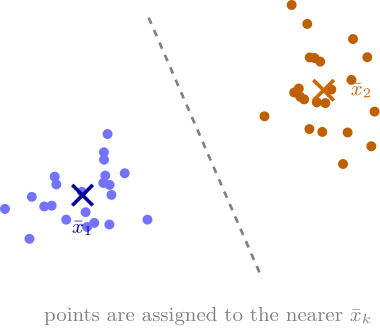

## Formal Optimization Problem

- Formally,

  $$
  \min_{\mathbf{S}} \sum_{k=1}^K \frac{1}{2|S_k|}\sum_{n, n' \in S_k} \|x_n - x_{n'}\|_2^2
  $$

- Using standard Euclidean norm between two elements in $S_k$

  $$
  \|x_n - x_{n'}\|_2^2 = \sum_{m=1}^M (x_{nm} - x_{n'm})^2
  $$

## k-means Objective Function

- Can prove that the previous objective is equivalent to minimizing the sum of the squared distances from the group $k$’s mean

  $$
  \min_{\mathbf{S}} \sum_{k=1}^K \sum_{n \in S_k} \|x_n - \bar{x}_k\|_2^2
  $$

- Where the mean of group $k$ is standard, and across all $m$ features

  $$
  \bar{x}_k \equiv \frac{1}{|S_k|}\sum_{n \in S_k} x_n
  $$

- Avoid different scales so the distances aren’t dominated by one feature

## How k-means Finds a Partition

- Searching over all partitions is infeasible, so k-means iterates from $K$ starting centers (e.g. $K$ random observations):
  1.  Assign each $x_n$ to the nearest center $\bar{x}_k$
  2.  Recompute each $\bar{x}_k$ as the mean of its assigned points
  3.  Repeat until no assignment changes
- Neither step increases the objective, so it converges, but to a local minimum that depends on the starting centers
- `KMeans` in scikit-learn runs this `n_init` times from different starts and keeps the lowest objective; fix `random_state` for reproducibility

## Rescale a Feature Before k-means

Two groups differ only in feature $1$; feature $2$ is noise on the same scale. Multiply feature $2$ by $1000$ and rerun k-means with $K = 2$.

**What does the partition look like?**

> **Note**
>
> **A.** Unchanged  
> **B.** Split by feature $1$ alone  
> **C.** Split by feature $2$ alone  
> **D.** k-means fails to converge

## Generating Data with Latent Groups

- Generate data with 2 features and 2 latent groups and see how k-means does
- First, put the data in a dataframe

In [5]:
np.random.seed(14)
mu_1 = np.array([0.0, 0.0]) # mean of k=1
mu_2 = np.array([1.0, 1.0]) # mean of k=2
sigma = np.array([[0.2, 0], [0, 0.2]]) # use same variance
N = 100 # observations per group
X_1 = np.random.multivariate_normal(mu_1, sigma, N)
X_2 = np.random.multivariate_normal(mu_2, sigma, N)
df_1 = pd.DataFrame({"f1": X_1[:, 0], "f2": X_1[:, 1], "k": 1})
df_2 = pd.DataFrame({"f1": X_2[:, 0], "f2": X_2[:, 1], "k": 2})
df = pd.concat([df_1, df_2], ignore_index=True)

## Plotting Code with Seaborn

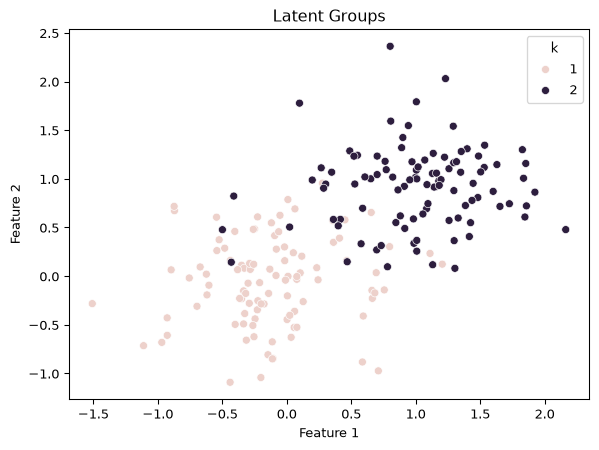

In [6]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="f1", y="f2",
  hue="k", ax=ax)
ax.set(xlabel="Feature 1", ylabel="Feature 2",
  title="Latent Groups")
plt.show()

## k-means to Recover the Latent Groups

- Run k-means with 2 clusters and check the results
- If the correlation is close to $1$ in absolute value then it recovered the latent groups

In [7]:
kmeans = KMeans(n_clusters=2, random_state=0)
k_hat = kmeans.fit_predict(df[["f1", "f2"]])
df["k_hat"] = k_hat + 1
corr = df["k"].corr(df["k_hat"])
print(f"Correlation between k and k_hat:{corr:.2f}")

Correlation between k and k_hat:0.88

## Did k-means Fail?

Suppose a run with two groups gives a correlation of $-0.98$ between the true $k$ and the assigned $\hat{k}$.

**Did k-means fail?**

> **Note**
>
> **A.** Yes: a success is near $+1$  
> **B.** No: cluster labels are arbitrary  
> **C.** Yes: the clusters are inverted  
> **D.** Cannot tell without the confusion matrix

## Confusion Matrix

- Cross-tabulate the latent $k$ against the assigned $\hat{k}$, as in the classification lecture, except that cluster labels are arbitrary

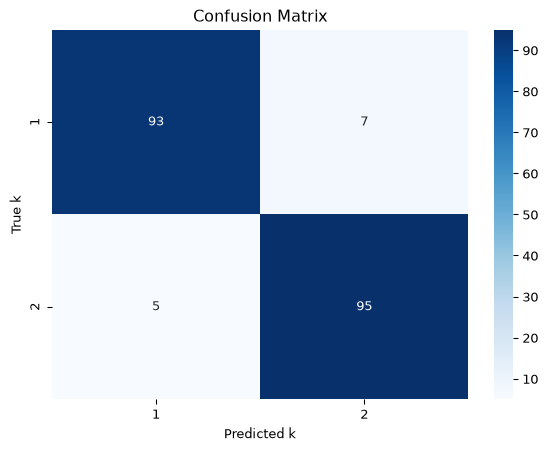

In [8]:
# compute confusion matrix
cm = confusion_matrix(df["k"], df["k_hat"])

# plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel('Predicted k')
plt.ylabel('True k')
plt.title('Confusion Matrix')
plt.show()

## Potentially Swap $\hat{k}$ and Compare

Label ordering is arbitrary, so the confusion matrix might require reordering to compare

In [9]:
if df['k'].corr(df['k_hat']) < 0:
  df['k_hat'] = df['k_hat'].replace({1: 2, 2: 1})
  print(f"Correlation now {df['k'].corr(df['k_hat'])}")

df['Cluster'] = df.apply(lambda x: rf"$k=\hat{{k}}={{{x['k']:.0g}}}$"
                         if x['k'] == x['k_hat'] else r'$k \neq \hat{k}$',
                         axis=1)

## Plotting the Uncovered Latent Groups

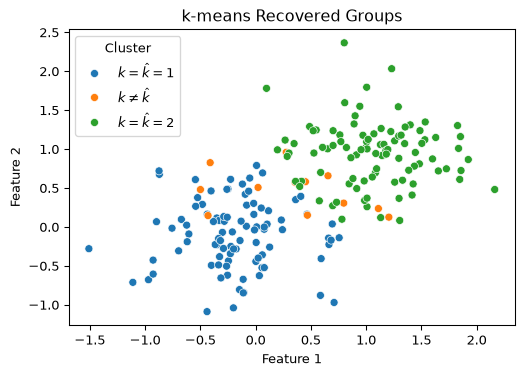

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=df, x="f1", y="f2",
  hue="Cluster", ax=ax)
ax.set(xlabel="Feature 1", ylabel="Feature 2",
       title="k-means Recovered Groups")
plt.show()

## Selecting the Number of Clusters

- A few of the tools people use to help:
  - [Elbow method](https://en.wikipedia.org/wiki/Determining_the_number_of_clusters_in_a_data_set#Elbow_method): plot objective function value as a function of $K$ and look for a kink
  - [Silhouette method](https://en.wikipedia.org/wiki/Silhouette_(clustering)): compare each point’s mean distance to its own cluster, $a$, with that to the nearest other cluster, $b$, averaging $(b - a) / \max(a, b)$
  - [Cross Validation](https://en.wikipedia.org/wiki/Determining_the_number_of_clusters_in_a_data_set#Cross-validation): split the data and see how well the clustering generalizes
- [sklearn docs on silhouette](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html)
- The same kink, in a [Scree plot](https://en.wikipedia.org/wiki/Scree_plot) of how much variation each component explains, chooses the number of components in the dimension reduction of the next lecture

## Example of Elbow

- Plot the within-cluster sum of squares as a function of $K$
- It falls to $0$ at $K = N$, but the kink suggests where the marginal improvement slows. See [Wikipedia](https://en.wikipedia.org/wiki/Determining_the_number_of_clusters_in_a_data_set#Elbow_method)

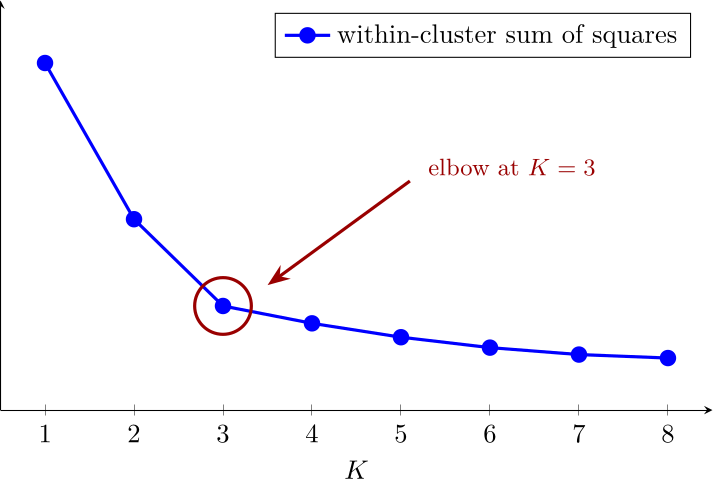

## Art vs. Science

- This is not an endorsement of any of these particular methods.
- Some may be helpful, but there will be some subjectivity and art in most cases
- Ultimately a domain-specific question

Use Economics, and don’t rely on technical tools alone

# Review Questions

## One Blob, Two Clusters

Run k-means with $K = 2$ on a single Gaussian blob with no latent groups.

**What happens?**

> **Note**
>
> **A.** One cluster comes back empty  
> **B.** It returns an error  
> **C.** Every point goes in one cluster  
> **D.** It splits the blob into two groups anyway, cutting across its longest axis

## More Clusters, Lower Objective?

Take the global optimum of the k-means objective for each $K$.

**How does the within-cluster sum of squares move as $K$ increases?**

> **Note**
>
> **A.** It weakly decreases, reaching $0$ at $K = N$  
> **B.** It can rise or fall  
> **C.** It strictly increases  
> **D.** It is constant once $K$ passes the true number of groups

## Two Seeds, Two Partitions

k-means with two different `random_state` values returns different partitions on the same data.

**Why?**

> **Note**
>
> **A.** The data have no clusters  
> **B.** The seed changes the distance norm  
> **C.** k-means is randomized by design, so both partitions are correct  
> **D.** The objective has many local minima, and the assign-then-average iteration stops at one that depends on the starting centers